<a href="https://colab.research.google.com/github/venkatvalluri2004/Code-alpha-Tasks/blob/main/3Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as ts
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc

In [44]:
sns.set()

In [ ]:
df = pd.read_csv('breast-cancer.csv')
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.drop('id', axis=1, inplace=True)


In [ ]:
print(f'The Number of Duplicate Records Are: {df.duplicated().sum()}')

The Number of Duplicate Records Are: 0


In [ ]:
df.shape

(569, 31)

In [ ]:
df.nunique()

,0
diagnosis,2
radius_mean,456
texture_mean,479
perimeter_mean,522
area_mean,539
smoothness_mean,474
compactness_mean,537
concavity_mean,537
concave points_mean,542
symmetry_mean,432


In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

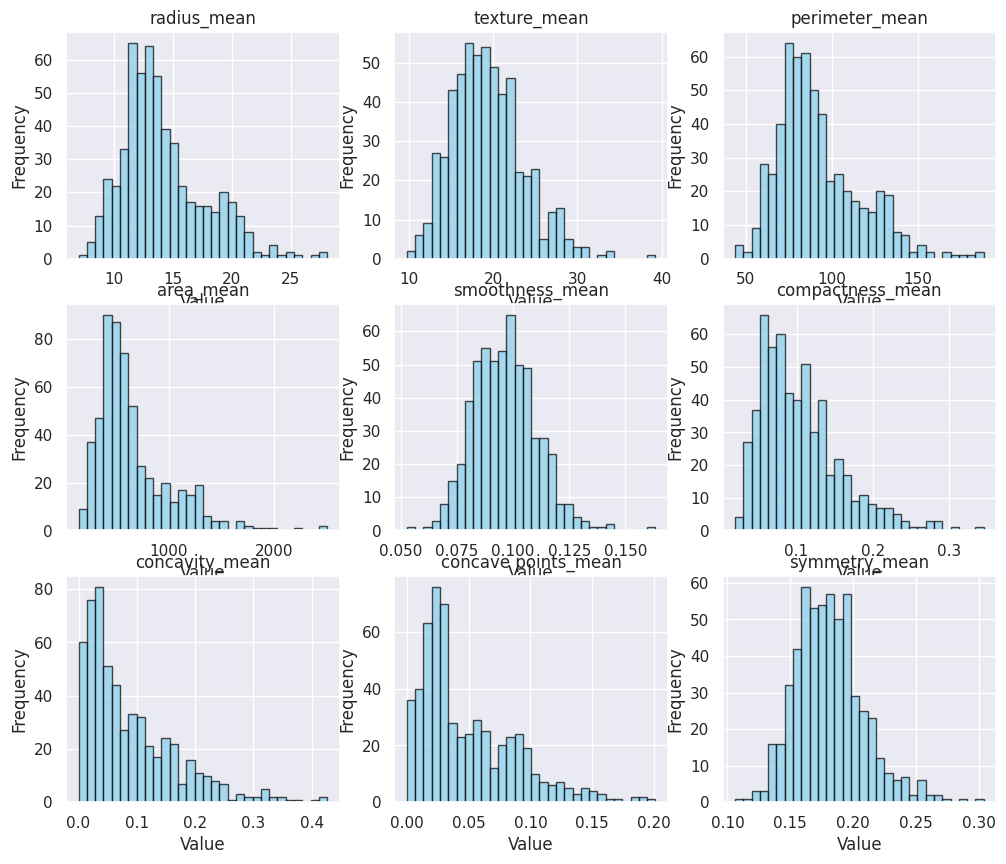

In [65]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 10))  # Adjust grid based on number of columns
axes = axes.flatten()
# Plot each column in a separate subplot
for i, col in enumerate(df.columns):
    if i < len(axes):  # Avoid index error
        df[col].hist(ax=axes[i], bins=30, alpha=0.7, color="skyblue", edgecolor="black")
        axes[i].set_title(col, fontsize=12)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")


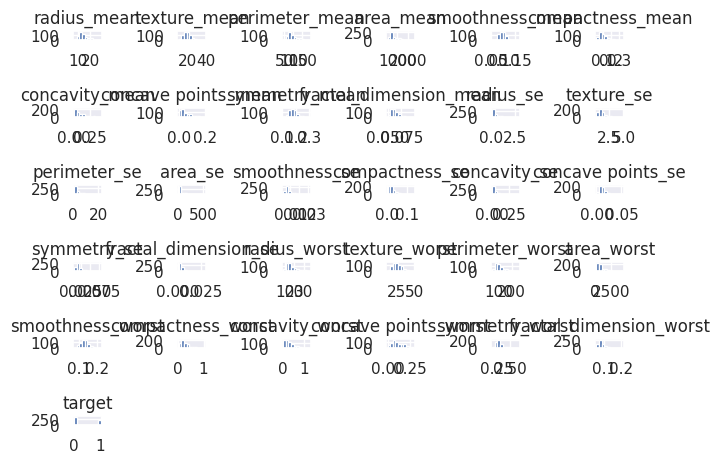

In [66]:
df.hist()
plt.tight_layout()

In [ ]:
df_mean = df.filter(like='_mean', axis=1).columns
df_se = df.filter(like='_se', axis=1).columns
df_worst = df.filter(like='_worst', axis=1).columns

In [ ]:
df_mean.shape, df_worst.shape, df_se.shape

((10,), (10,), (10,))

In [ ]:
df.skew(numeric_only=1)

,0
radius_mean,0.942380
texture_mean,0.650450
perimeter_mean,0.990650
area_mean,1.645732
smoothness_mean,0.456324
compactness_mean,1.190123
concavity_mean,1.401180
concave points_mean,1.171180
symmetry_mean,0.725609
fractal_dimension_mean,1.304489


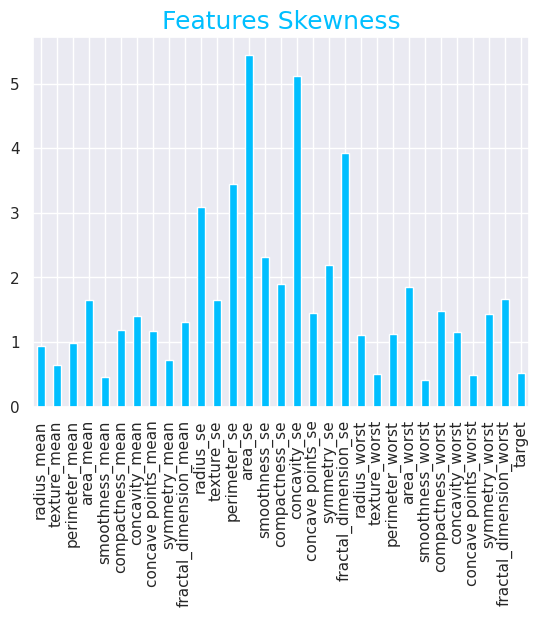

In [46]:
df.skew(numeric_only=True).plot(kind='bar', color='deepskyblue')
plt.title('Features Skewness', fontsize=18, color='deepskyblue')
plt.xticks(rotation=90)
plt.show()

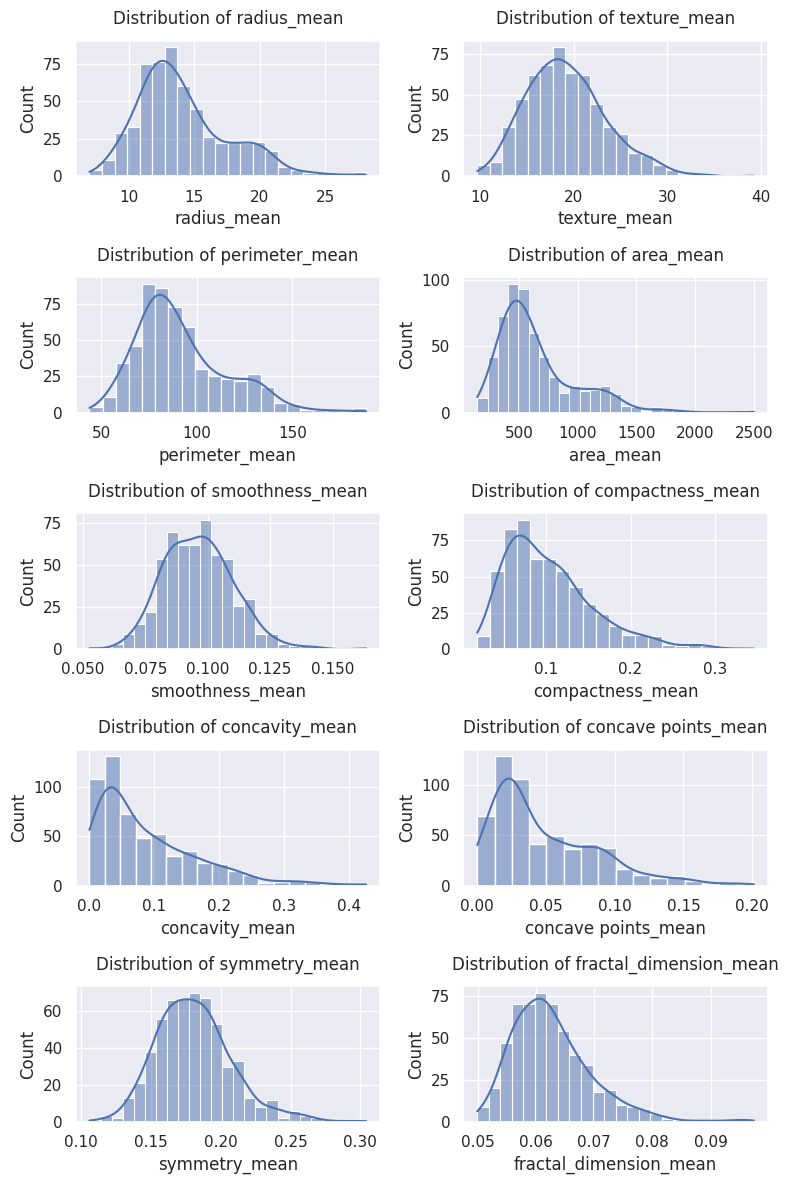

In [ ]:
#mean Features
rows = 5
col = 2

fig, ax = plt.subplots(nrows=rows, ncols=col, figsize=(8,12))

for i in range(rows):
  for j in range(col):
    sns.histplot(x=df_mean[i*col+j], data=df, kde=True, ax=ax[i,j])
    ax[i,j].set_title(f'Distribution of {df_mean[i*col+j]}', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

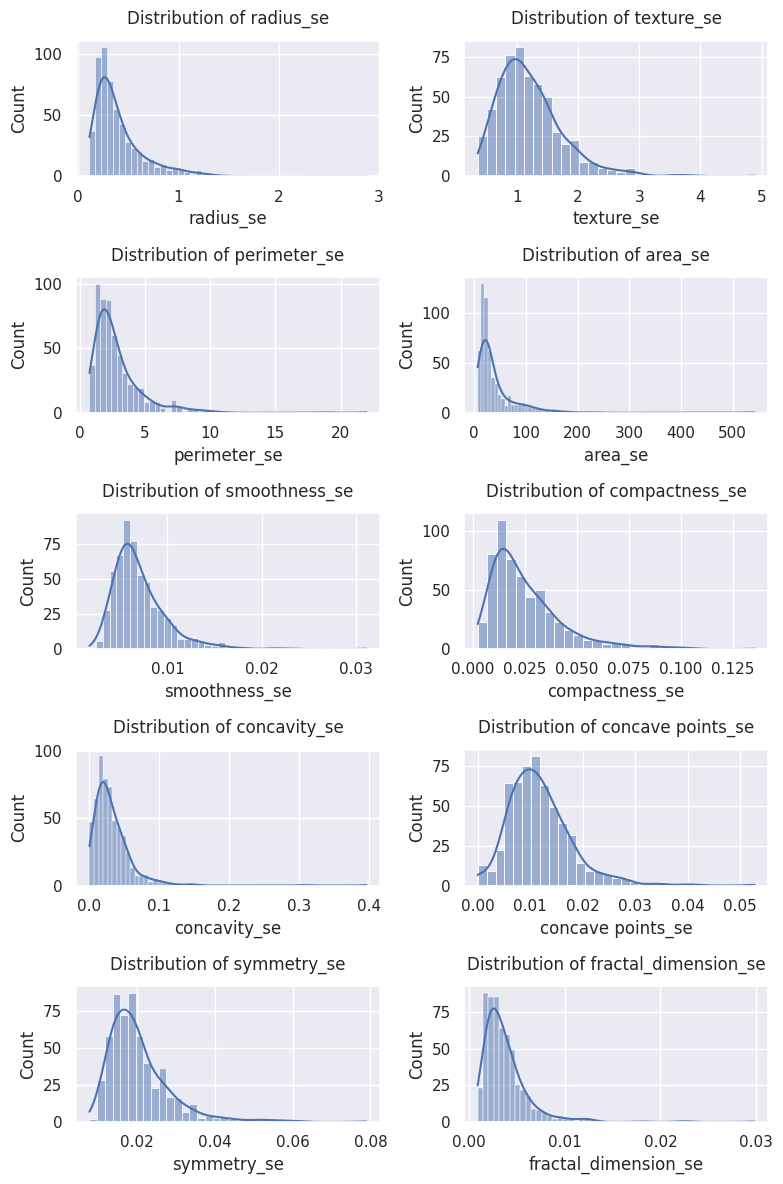

In [ ]:
#_se Features
rows = 5
col = 2

fig, ax = plt.subplots(nrows=rows, ncols=col, figsize=(8,12))

for i in range(rows):
  for j in range(col):
    sns.histplot(x=df_se[i*col+j], data=df, kde=True, ax=ax[i,j])
    ax[i,j].set_title(f'Distribution of {df_se[i*col+j]}', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

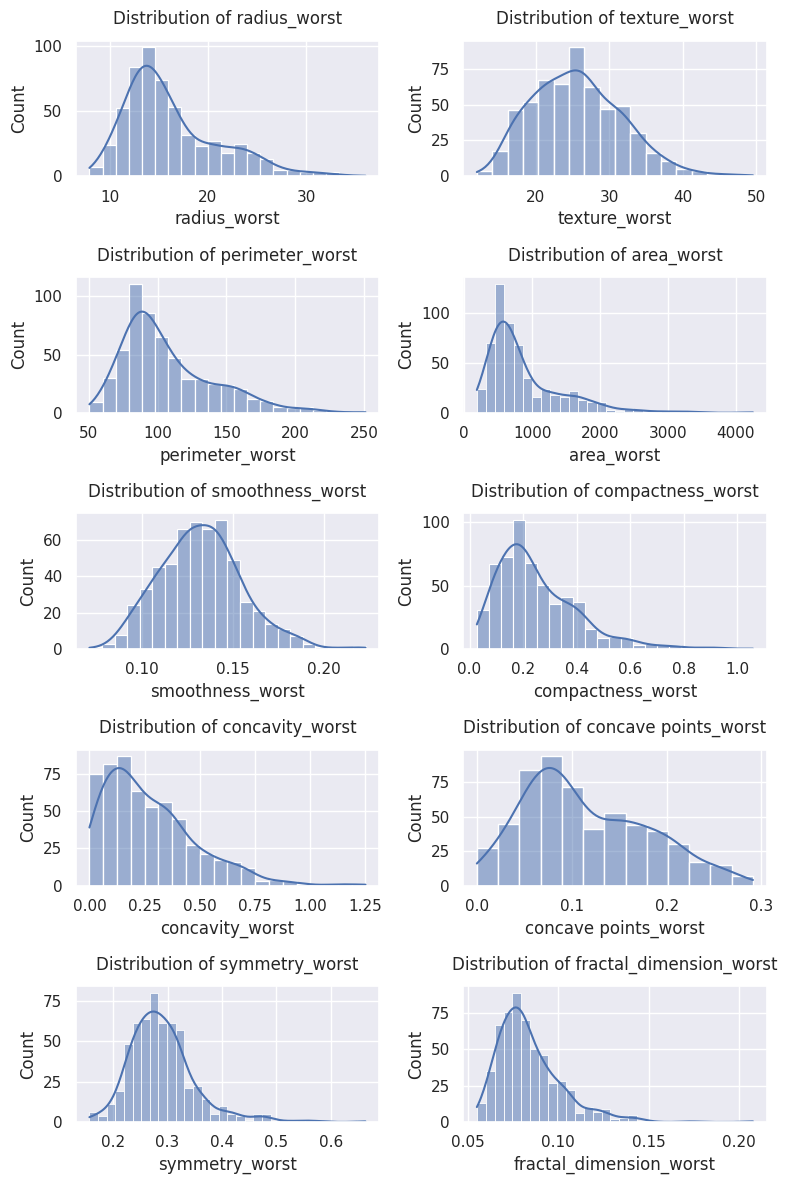

In [ ]:
#worst Features
rows = 5
col = 2
fig, ax = plt.subplots(nrows=rows, ncols=col, figsize=(8,12))
for i in range(rows):
  for j in range(col):
    sns.histplot(x=df_worst[i*col+j], data=df, kde=True, ax=ax[i,j])
    ax[i,j].set_title(f'Distribution of {df_worst[i*col+j]}', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

In [ ]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [27]:
total = df.shape[0]
target_count = df['diagnosis'].value_counts()

print(f'Percentage of Cancerous Target (M- Malignant): {(target_count.get("M")/total)*100: .2f}-%')
print(f'Percentage of Not-Cancerous Target (B-Benign): {(target_count.get("B")/total)*100: .2f}-%')

Percentage of Cancerous Target (M- Malignant):  37.26-%
Percentage of Not-Cancerous Target (B-Benign):  62.74-%


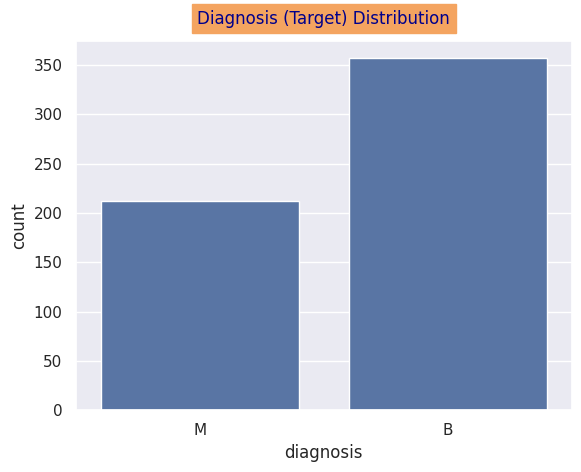

In [28]:
sns.countplot(x='diagnosis', data=df)
plt.title(f'Diagnosis (Target) Distribution',  color='darkblue',
                        backgroundcolor='sandybrown', pad=12)
plt.show()

In [29]:
df['target']  = df['diagnosis'].map({'M':1, 'B':0})
df.drop('diagnosis', axis=1, inplace=True)

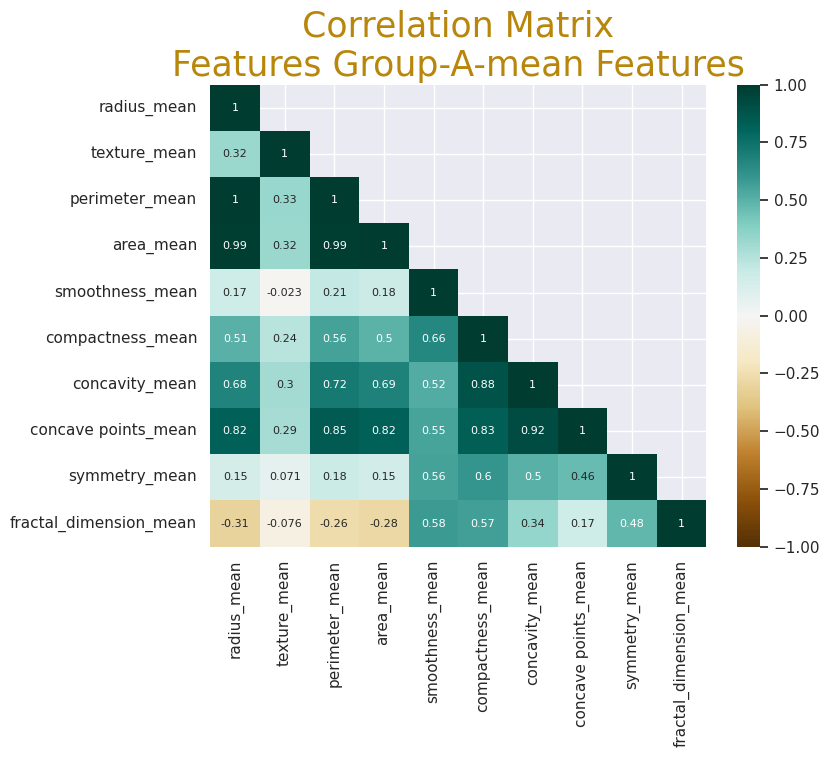

In [32]:
#mean Features
corr=df[df_mean].corr()

plt.figure(figsize=(8,6))
mask = ~np.tril(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, annot_kws={"size": 8}, cmap='BrBG', vmin=-1, vmax=1)

title = r'Correlation Matrix' + '\nFeatures Group-A-mean Features'

plt.title(title, loc='center', fontsize=25, color='darkgoldenrod')
plt.show()

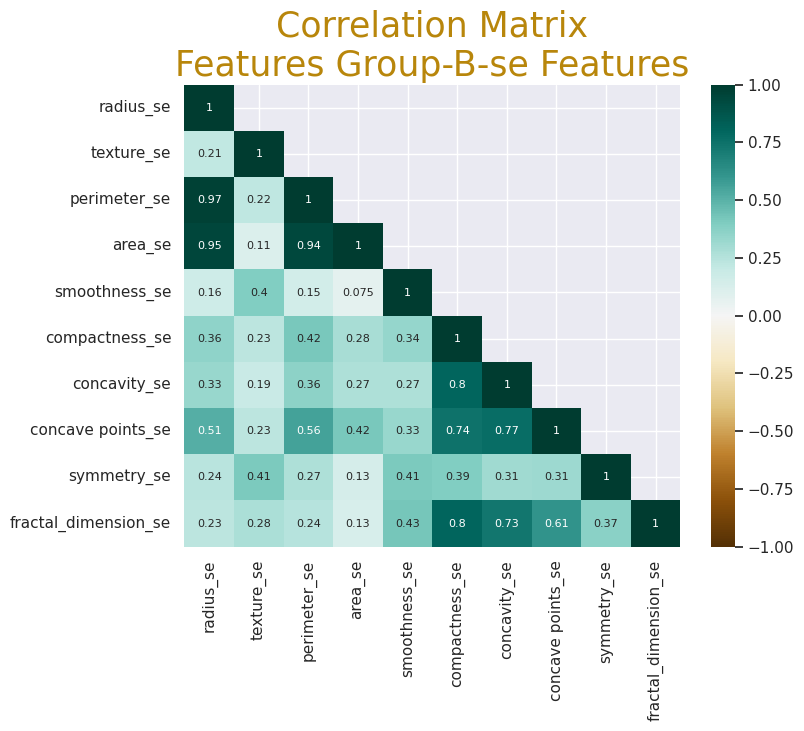

In [33]:
#se Features
corr=df[df_se].corr()
plt.figure(figsize=(8,6))
mask = ~np.tril(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, annot_kws={"size": 8}, cmap='BrBG', vmin=-1, vmax=1)
title = r'Correlation Matrix' + '\nFeatures Group-B-se Features'
plt.title(title, loc='center', fontsize=25, color='darkgoldenrod')
plt.show()

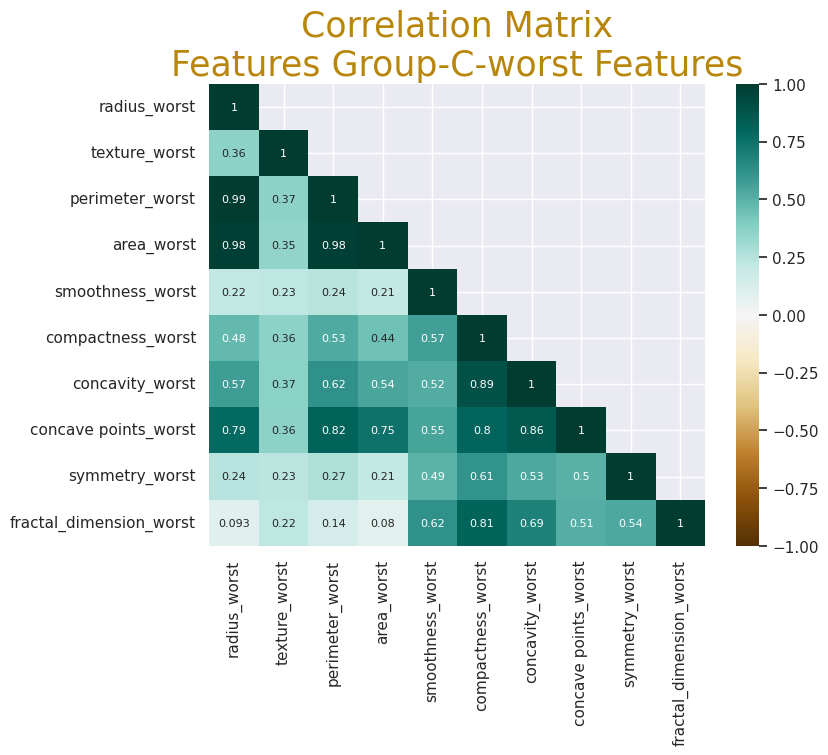

In [35]:
#worst Features
corr=df[df_worst].corr()
plt.figure(figsize=(8,6))
mask = ~np.tril(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, annot_kws={"size": 8}, cmap='BrBG', vmin=-1, vmax=1)
title = r'Correlation Matrix' + '\nFeatures Group-C-worst Features'
plt.title(title, loc='center', fontsize=25, color='darkgoldenrod')
plt.show()

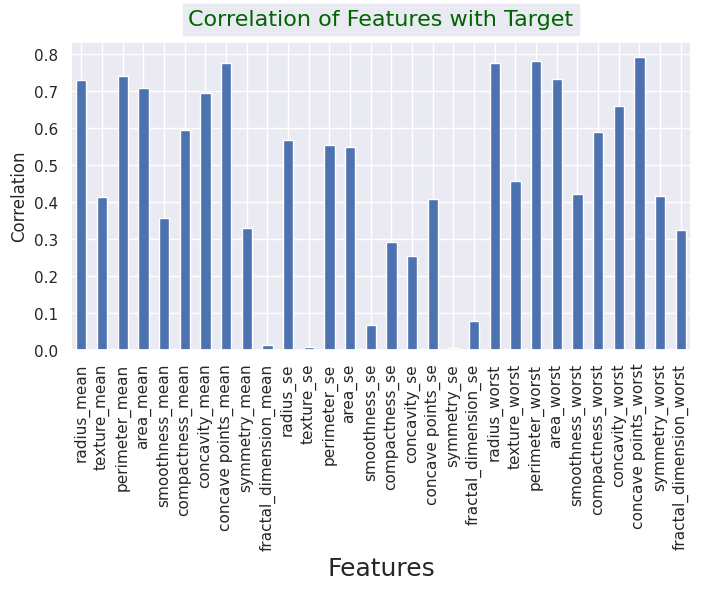

In [39]:
corr_target = df.corr()['target'].abs()
plt.figure(figsize=(8, 4))
corr_target.drop('target').plot(kind='bar')
plt.title('Correlation of Features with Target', fontsize=16,
          backgroundcolor= '#EAEAF2', color='darkgreen', pad=12)
plt.ylabel('Correlation', fontsize=12)
plt.xlabel('Features', fontsize=18)
plt.xticks(rotation=90)
plt.show()

In [47]:
X=df.drop('target',axis=1)
y=df['target']
X_train, X_test,y_train,y_test=ts(X,y,test_size=0.2, shuffle=True, stratify=y, random_state=32)

In [48]:
Scaler = StandardScaler()
Scaler.fit(X_train)
Xtrain_std = Scaler.transform(X_train)
Xtest_std = Scaler.transform(X_test)

y_train = y_train.values
y_test = y_test.values

In [50]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(Xtrain_std, y_train)
feature_importances = rf_classifier.feature_importances_

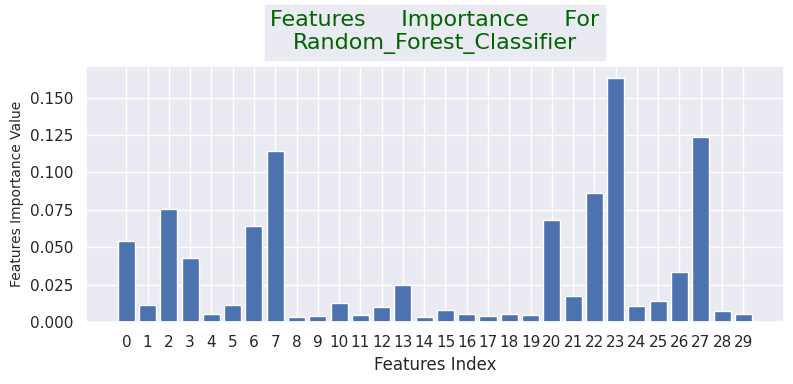

In [51]:
plt.figure(figsize=(8,4))
plt.bar(range(30), feature_importances) #feature indices vs feat importance
plt.xticks(range(30))
plt.title('Features     Importance     For\nRandom_Forest_Classifier', fontsize=16,
          backgroundcolor= '#EAEAF2', color='darkgreen', pad=12)
plt.xlabel('Features Index', fontsize=12)
plt.ylabel('Features Importance Value', fontsize=10)
plt.tight_layout()
plt.show()

In [52]:
y_pred=rf_classifier.predict(Xtest_std)
train_acc = accuracy_score(y_true=y_train, y_pred=rf_classifier.predict(Xtrain_std))*100
test_acc = accuracy_score(y_true=y_test, y_pred=y_pred)*100
print(f'Training Accuracy:   {train_acc: .2f}\nTest Accuracy    :   {test_acc: .2f}\n')
print(f'CLASSIFICATION REPORT: \n\n{classification_report(y_test,y_pred)}')
print(f'CONFUSION MATRIX: \n\n{confusion_matrix(y_test,y_pred)}')

Training Accuracy:    100.00
Test Accuracy    :    97.37

CLASSIFICATION REPORT: 

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

CONFUSION MATRIX: 

[[71  1]
 [ 2 40]]


In [53]:
k=10 #Assume the desired number of features
sorted_indices = np.argsort(feature_importances)[::-1]
desired_feat_index = sorted_indices[:k]
print(f'Features at the following indices are the top {k} most important \
features for \nRandom_Forest_Classifier are:\n{desired_feat_index}')

Features at the following indices are the top 10 most important features for 
Random_Forest_Classifier are:
[23 27  7 22  2 20  6  0  3 26]


In [54]:
Ks = np.arange(1,30,dtype='int')
Accuracy_List = []
for k in Ks:
    desired_feat_index = sorted_indices[:k] #Get the top k-features indices
    X_train_new = Xtrain_std[:,desired_feat_index] #Slice the top k-features
    X_test_new = Xtest_std[:,desired_feat_index]
    rf_classifier.fit(X_train_new, y_train) #Model Training
    y_pred=rf_classifier.predict(X_test_new) #Model Prediction
    train_acc = accuracy_score(y_true=y_train, y_pred=rf_classifier.predict(X_train_new))*100
    test_acc = accuracy_score(y_true=y_test, y_pred=y_pred)*100
    acc = [k, round(train_acc,2), round(test_acc,2)]
    Accuracy_List.append(acc)

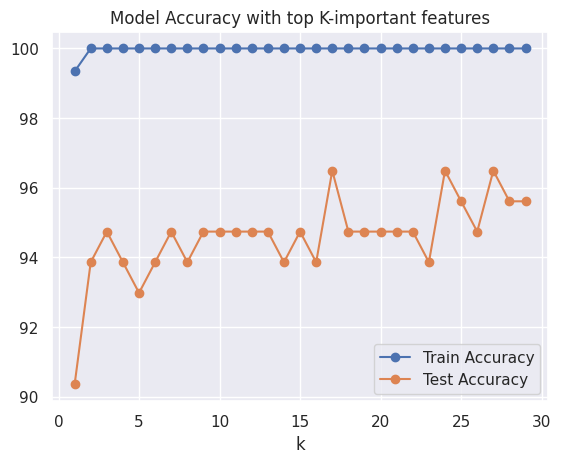

In [55]:
K_df = pd.DataFrame(Accuracy_List, columns= ["k", "Train Accuracy", "Test Accuracy"])
K_df.plot(kind='line',marker='o',x='k')
plt.title('Model Accuracy with top K-important features')
plt.grid('on')
plt.show()

In [56]:
k=17

In [57]:
desired_feat_index = sorted_indices[:k] #Get the top k-features indices
X_train_new = Xtrain_std[:,desired_feat_index] #Slice the top k-features
X_test_new = Xtest_std[:,desired_feat_index]
rf_classifier.fit(X_train_new, y_train) #Model Training
y_pred=rf_classifier.predict(X_test_new) #Model Prediction
train_acc = accuracy_score(y_true=y_train, y_pred=rf_classifier.predict(X_train_new))*100
test_acc = accuracy_score(y_true=y_test, y_pred=y_pred)*100
print(f'Training Accuracy:   {train_acc: .2f}\nTest Accuracy    :   {test_acc: .2f}\n')
print(f'CLASSIFICATION REPORT: \n\n{classification_report(y_test,y_pred)}')
print(f'CONFUSION MATRIX: \n\n{confusion_matrix(y_test,y_pred)}')

Training Accuracy:    100.00
Test Accuracy    :    96.49

CLASSIFICATION REPORT: 

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

CONFUSION MATRIX: 

[[71  1]
 [ 3 39]]


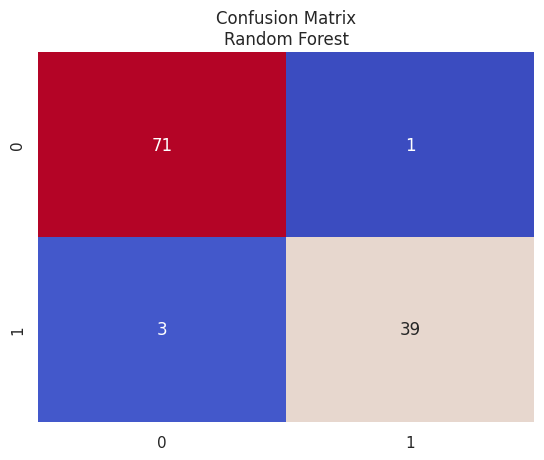

In [58]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, cbar=0, cmap='coolwarm')
plt.title('Confusion Matrix\nRandom Forest')
plt.show()

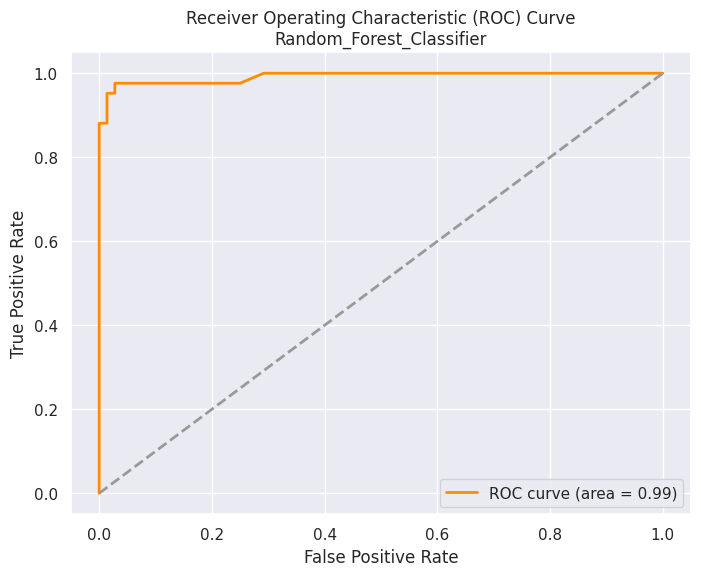

In [59]:
predicted_probabilities = rf_classifier.predict_proba(X_test_new)
fpr, tpr, thresholds = roc_curve(y_test, predicted_probabilities[:,1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color=(0.6, 0.6, 0.6), lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve\nRandom_Forest_Classifier')
plt.legend(loc='lower right')
plt.show()